In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import pandas as pd

# Carregar o dataset
df = pd.read_csv("../../dataset/Combined_dataset.csv")



,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,12-01-1974,0.059248,1.30,8.1500,0.011917,8.07500,9.885,0.343917,11.73155,100.0,Excellent
1,Canada,SE649035-145565,River,12-01-1975,0.039821,1.38,7.8000,0.009417,7.73333,10.150,0.449083,11.82009,100.0,Excellent
2,Canada,SE649035-145565,River,12-01-1976,0.031341,2.23,7.8000,0.011000,7.46667,10.235,0.220750,14.87472,100.0,Excellent
3,Canada,SE649035-145565,River,12-01-1977,0.020501,1.61,8.1500,0.012333,7.78333,11.116,0.572250,15.89293,100.0,Excellent
4,Canada,SE649035-145565,River,12-01-1978,0.020023,1.64,4.3708,0.006182,7.10000,7.068,0.371091,15.22888,100.0,Excellent


# Correlações entre Variáveis


## Matriz de correlação
Vamos calcular a matriz de correlação entre as variáveis numéricas para identificar a intensidade e a direção das relações lineares entre elas.


---
**Pergunta que queremos responder**

*  As variáveis numéricas do dataset apresentam relações lineares entre si?
*   Quais variáveis possuem associação positiva ou negativa?


---
**Objetivo**


*   Quantificar o grau de correlação entre todas as variáveis numéricas do dataset
*    identificar padrões iniciais de associação que possam orientar análises posteriores





In [4]:
# Selecionando apenas colunas numéricas
numerical_cols = df.select_dtypes(include=['number']).columns
df_num = df[numerical_cols]

# Calculando matriz de correlação
correlation_matrix = df_num.corr(numeric_only=True)

print("Matriz de correlação:")
display(correlation_matrix)

Matriz de correlação:


,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values
Ammonia (mg/l),1.000000,0.428977,0.009518,0.220463,-0.075654,0.033522,0.042392,0.010995,-0.392058
Biochemical Oxygen Demand (mg/l),0.428977,1.000000,0.017516,0.133585,-0.041029,0.008866,0.039014,0.011532,-0.321557
Dissolved Oxygen (mg/l),0.009518,0.017516,1.000000,0.005999,0.075307,-0.234157,0.065263,0.057312,-0.029791
Orthophosphate (mg/l),0.220463,0.133585,0.005999,1.000000,-0.086962,0.080834,0.509826,0.198994,-0.659170
pH (ph units),-0.075654,-0.041029,0.075307,-0.086962,1.000000,0.064900,-0.047687,-0.030362,0.079743
Temperature (cel),0.033522,0.008866,-0.234157,0.080834,0.064900,1.000000,-0.001426,-0.021157,-0.109112
Nitrogen (mg/l),0.042392,0.039014,0.065263,0.509826,-0.047687,-0.001426,1.000000,0.520721,-0.610675
Nitrate (mg/l),0.010995,0.011532,0.057312,0.198994,-0.030362,-0.021157,0.520721,1.000000,-0.307599
CCME_Values,-0.392058,-0.321557,-0.029791,-0.659170,0.079743,-0.109112,-0.610675,-0.307599,1.000000


A matriz de correlação revelou que a maioria das variáveis apresenta correlação fraca, indicando baixa associação linear entre grande parte dos pares. No entanto, algumas relações moderadas se destacaram, especialmente entre Orthophosphate (mg/l) e CCME_Values (-0.659), Nitrogen (mg/l) e CCME_Values (-0.611), Nitrogen (mg/l) e Nitrate (mg/l) (0.521), e Orthophosphate (mg/l) e Nitrogen (mg/l) (0.510). Esses resultados sugerem que variáveis associadas à presença de nutrientes e poluentes possuem maior relação com a variação do índice de qualidade da água. Em especial, o aumento de ortofosfato e nitrogênio tende a estar associado à redução de CCME_Values. Já variáveis como pH, temperatura e oxigênio dissolvido apresentaram correlações fracas, indicando menor associação linear no conjunto analisado.

## Heatmap de correlação
Vamos visualizar a matriz de correlação por meio de um heatmap, facilitando a identificação visual das relações mais relevantes.


---
**Pergunta que queremos responder**


*   Quais relações entre variáveis se destacam visualmente em termos de intensidade e direção?


---

**Objetivo**


*   utilizar uma representação visual para destacar padrões de correlação, facilitando a identificação de relações fortes, moderadas ou fracas entre variáveis





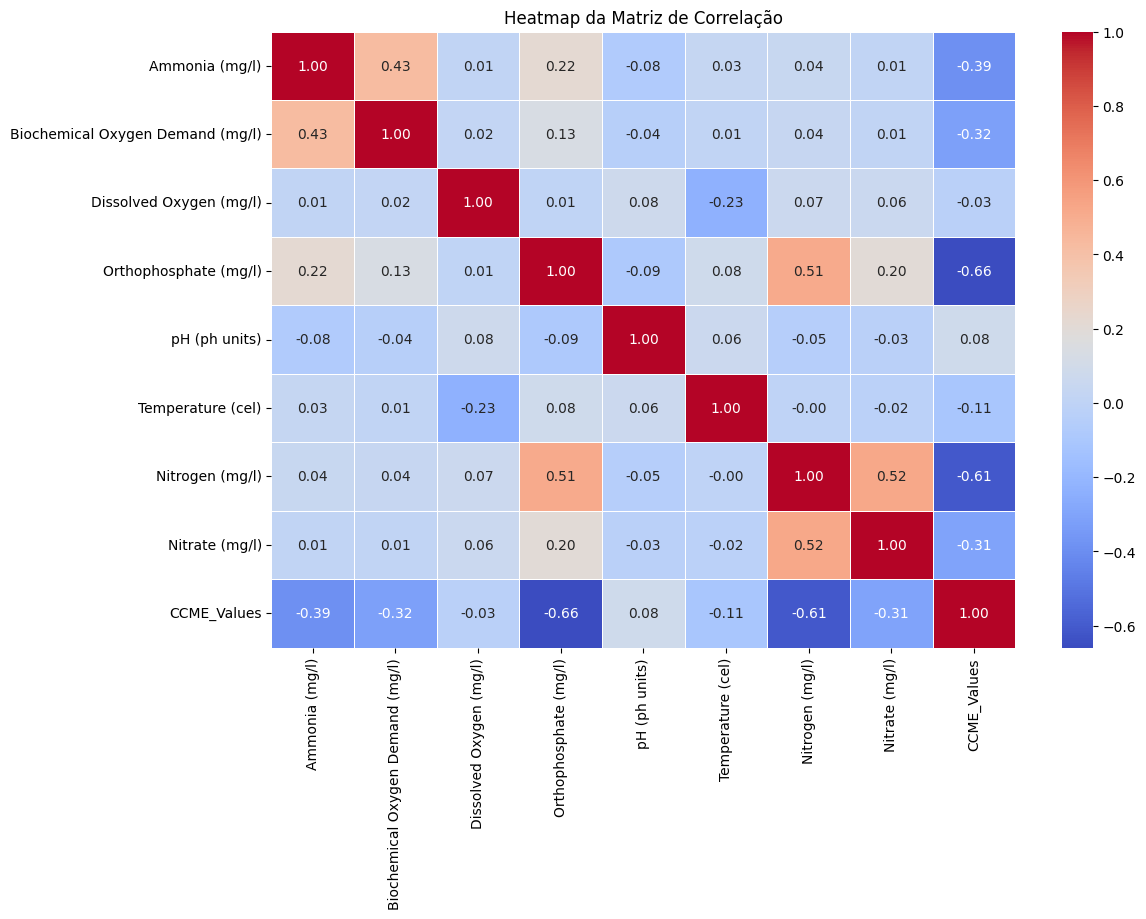

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap da Matriz de Correlação")
plt.show()

O heatmap da matriz de correlação permitiu visualizar de forma mais clara a intensidade e a direção das relações entre as variáveis numéricas. Observou-se que a maioria das correlações é fraca, indicando ausência de relações lineares significativas para grande parte dos pares.

No entanto, algumas associações se destacaram, especialmente entre Orthophosphate (mg/l) e CCME_Values (-0.66), Nitrogen (mg/l) e CCME_Values (-0.61), além das relações positivas entre Nitrogen (mg/l) e Nitrate (mg/l) (0.52) e entre Orthophosphate (mg/l) e Nitrogen (mg/l) (0.51).

Esses resultados indicam um padrão consistente, no qual variáveis associadas à presença de nutrientes apresentam correlação negativa com o índice de qualidade da água (CCME_Values), sugerindo que o aumento desses compostos está relacionado à redução da qualidade.

Por outro lado, variáveis como pH, temperatura e oxigênio dissolvido apresentaram correlações predominantemente fracas, indicando menor associação linear com as demais variáveis no dataset analisado.

De forma geral, o heatmap evidencia que parâmetros relacionados à carga de nutrientes desempenham um papel mais relevante na variação do índice de qualidade da água, embora seja importante destacar que correlação não implica causalidade. Assim, essas relações devem ser analisadas em conjunto com outras abordagens, como gráficos de dispersão, para uma compreensão mais completa dos dados.

## Identificação de pares relevantes
Vamos organizar os pares de variáveis com base na magnitude da correlação, destacando aqueles com maior relevância.


---
**Pergunta que queremos responder**


*   Quais pares de variáveis apresentam correlação mais forte (positiva ou negativa)?


---
**Objetivo**


*   identificar e priorizar pares de variáveis com maior associação, permitindo focar a análise em relações mais significativas






In [6]:
# Transformando a matriz em pares
corr_pairs = correlation_matrix.unstack()

# Removendo autocorrelação
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Convertendo para DataFrame
corr_pairs_df = corr_pairs.reset_index()
corr_pairs_df.columns = ['Variável 1', 'Variável 2', 'Correlação']

# Removendo duplicações (A,B) e (B,A)
corr_pairs_df['Par_Ordenado'] = corr_pairs_df.apply(
    lambda row: tuple(sorted([row['Variável 1'], row['Variável 2']])),
    axis=1
)

corr_pairs_df = corr_pairs_df.drop_duplicates(subset='Par_Ordenado').drop(columns='Par_Ordenado')

# Ordenando pela magnitude da correlação
corr_pairs_df = corr_pairs_df.sort_values(by='Correlação', key=abs, ascending=False)

print("Pares de variáveis ordenados pela magnitude da correlação:")
display(corr_pairs_df)

Pares de variáveis ordenados pela magnitude da correlação:


,Variável 1,Variável 2,Correlação
31,Orthophosphate (mg/l),CCME_Values,-0.659170
55,Nitrogen (mg/l),CCME_Values,-0.610675
54,Nitrogen (mg/l),Nitrate (mg/l),0.520721
29,Orthophosphate (mg/l),Nitrogen (mg/l),0.509826
0,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),0.428977
7,Ammonia (mg/l),CCME_Values,-0.392058
15,Biochemical Oxygen Demand (mg/l),CCME_Values,-0.321557
63,Nitrate (mg/l),CCME_Values,-0.307599
20,Dissolved Oxygen (mg/l),Temperature (cel),-0.234157
2,Ammonia (mg/l),Orthophosphate (mg/l),0.220463


## Seleção de pares mais relevantes
Vamos filtrar os pares com correlação moderada ou forte para análise detalhada.


---
**Pergunta que queremos responder**


*  Quais relações são suficientemente relevantes para justificar uma análise visual mais aprofundada?


---
**Objetivo**

*   selecionar apenas os pares mais significativos, evitando análises desnecessárias e mantendo o foco em relações relevantes.







In [7]:
# Filtrando pares com correlação relevante
relevant_pairs = corr_pairs_df[abs(corr_pairs_df['Correlação']) >= 0.5]

print("Pares com correlação moderada ou forte:")
display(relevant_pairs)

Pares com correlação moderada ou forte:


,Variável 1,Variável 2,Correlação
31,Orthophosphate (mg/l),CCME_Values,-0.659170
55,Nitrogen (mg/l),CCME_Values,-0.610675
54,Nitrogen (mg/l),Nitrate (mg/l),0.520721
29,Orthophosphate (mg/l),Nitrogen (mg/l),0.509826


A seleção dos pares mais relevantes mostrou que apenas quatro pares apresentaram correlação moderada ou forte no dataset, indicando que as relações lineares mais expressivas estão concentradas em poucas variáveis. Destacaram-se os pares Orthophosphate (mg/l) × CCME_Values (-0.659) e Nitrogen (mg/l) × CCME_Values (-0.611), sugerindo que o aumento desses compostos está associado à redução do índice de qualidade da água. Também foram observadas correlações positivas entre Nitrogen (mg/l) × Nitrate (mg/l) (0.521) e Orthophosphate (mg/l) × Nitrogen (mg/l) (0.510), indicando que essas variáveis tendem a variar em conjunto. No geral, os resultados reforçam a relevância dos parâmetros ligados à carga de nutrientes no comportamento de CCME_Values.

## Scatter plots dos pares relevantes
Vamos visualizar graficamente os pares mais relevantes para entender melhor a relação entre as variáveis.


---
**Pergunta que queresmos responder**


*   As relações identificadas na correlação são realmente lineares? Existem padrões, dispersões ou outliers?



---
**Objetivo**


*   confirmar visualmente as relações identificadas numericamente, analisando o comportamento real dos dados


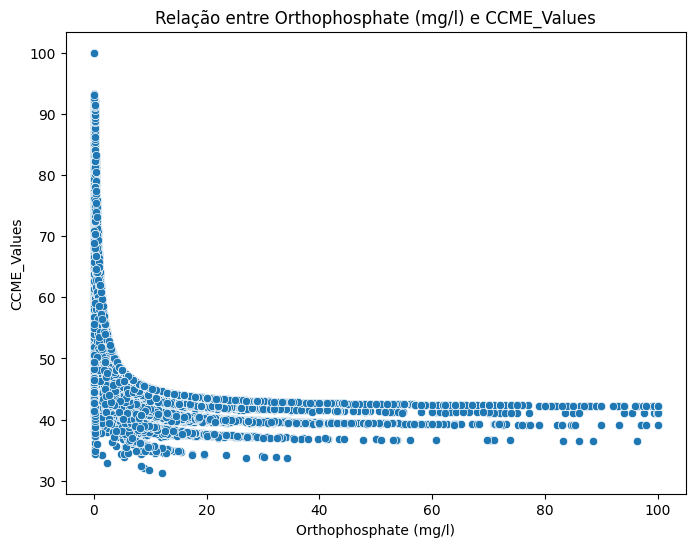

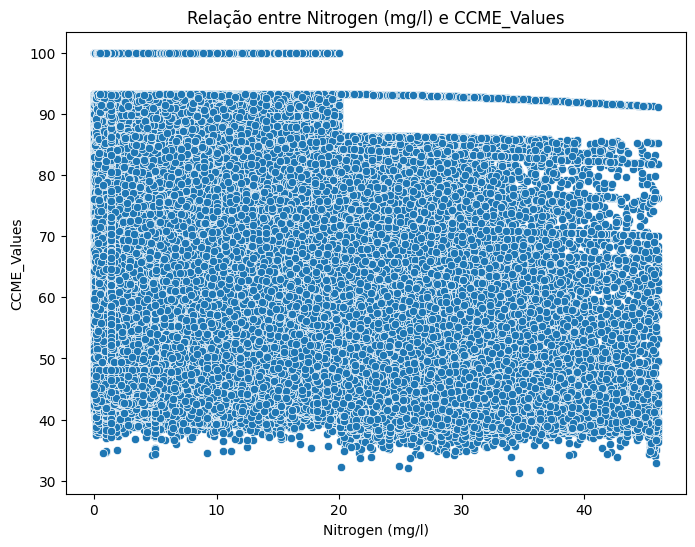

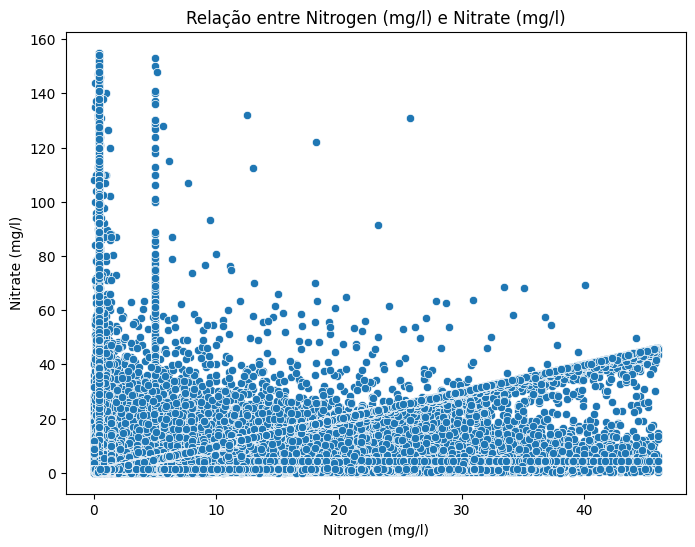

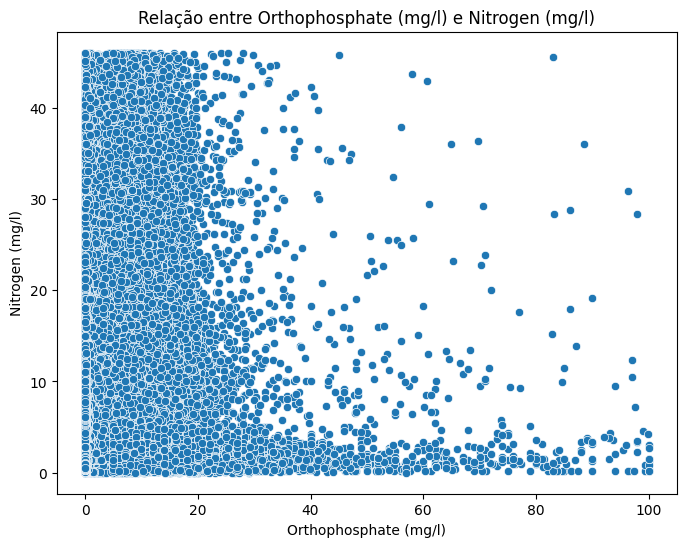

In [8]:
for _, row in relevant_pairs.head(5).iterrows():
    x = row['Variável 1']
    y = row['Variável 2']

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"Relação entre {x} e {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

Os gráficos de dispersão permitiram analisar visualmente as relações entre os pares de variáveis selecionados, complementando a interpretação da matriz de correlação. Observou-se que, embora algumas correlações indiquem associações moderadas, essas relações nem sempre se manifestam de forma linear ou consistente nos dados.

A relação entre Orthophosphate (mg/l) e CCME_Values apresentou uma tendência negativa clara, porém com comportamento não linear, sugerindo que aumentos iniciais de ortofosfato estão associados a quedas mais acentuadas no índice de qualidade da água, seguidas de uma estabilização.

Por outro lado, a relação entre Nitrogen (mg/l) e CCME_Values, apesar da correlação negativa moderada, apresentou alta dispersão dos pontos, indicando que essa associação não é uniforme ao longo do dataset.

As relações entre Nitrogen (mg/l) e Nitrate (mg/l) e entre Orthophosphate (mg/l) e Nitrogen (mg/l) apresentaram tendência positiva, mas com significativa variabilidade, sugerindo que essas variáveis podem estar associadas, porém não de forma estritamente linear.

De modo geral, os scatter plots evidenciam que as relações entre variáveis são mais complexas do que indicam os coeficientes de correlação, reforçando a importância da análise visual para uma compreensão mais completa dos dados.